# 1. Setup

In [1]:
import sys
sys.path.append("/home/565/pv3484/aus_substation_electricity")
%cd /home/565/pv3484/aus_substation_electricity
!pwd

/home/565/pv3484/aus_substation_electricity
/home/565/pv3484/aus_substation_electricity


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as mpatches


# 2. Load data

In [3]:
demand_rank = pd.read_csv("/home/565/pv3484/aus_substation_electricity/data/cleaned_data/full_nsw_relative_rank.csv")
weather = pd.read_csv("/home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v3/weather_station_066062.csv")

print("demand_rank shape:", demand_rank.shape)
print("weather shape:", weather.shape)

demand_rank shape: (828912, 39)
weather shape: (280512, 11)


# 3. Filter Mosman and build paired dataframe

In [4]:
station_code = 'MOSMA'
station_full_name = 'Mosman'

# Filter Mosman demand rank
mosman_rank = demand_rank[
    demand_rank['station_code'].str.contains('MOS', case=False, na=False)
].copy()

rank_cols = ['date', 'holiday_group', 'is_weekend', 'is_holiday'] + \
            [c for c in mosman_rank.columns if 'rank' in c.lower()]
mosman_rank = mosman_rank[rank_cols]
mosman_rank['date'] = pd.to_datetime(mosman_rank['date']).dt.normalize()

# Aggregate weather into time blocks (2004-2017)
weather['timestamp_utc'] = pd.to_datetime(weather['timestamp_utc'], utc=True)
weather = weather[
    (weather['timestamp_utc'].dt.year >= 2004) &
    (weather['timestamp_utc'].dt.year <= 2017)
]
weather['timestamp_local'] = weather['timestamp_utc'].dt.tz_convert('Australia/Sydney').dt.tz_localize(None)  # Fixed: convert UTC -> Sydney local (handles AEST +10 / AEDT +11)
weather['date'] = weather['timestamp_local'].dt.normalize()
weather['time_block'] = weather['timestamp_local'].dt.hour.map(lambda h:
    '00_04' if h < 4 else '04_10' if h < 10 else '10_15' if h < 15 else '15_20' if h < 20 else '20_24'
)

met_cols = ['temp', 'dewpoint', 'relative_humidity']
weather_agg = weather.groupby(['date', 'time_block'])[met_cols].mean().reset_index()

weather_wide = weather_agg.pivot(index='date', columns='time_block', values=met_cols)
weather_wide.columns = [f"{var}_{block}" for var, block in weather_wide.columns]
weather_wide = weather_wide.reset_index()
weather_wide['date'] = pd.to_datetime(weather_wide['date']).dt.normalize()

# Merge
paired = mosman_rank.merge(weather_wide, on='date', how='left')

print("paired shape:", paired.shape)
print(paired[['date', 'holiday_group', 'is_weekend', 'is_holiday', 'temp_00_04', 'relative_humidity_00_04', 'dewpoint_00_04']].head())

paired shape: (9868, 34)
        date   holiday_group  is_weekend  is_holiday  temp_00_04  \
0 2004-01-01  New Year's Day       False        True         NaN   
1 2004-01-02  New Year's Day       False       False      21.375   
2 2004-01-03  New Year's Day        True       False      21.400   
3 2004-01-04  New Year's Day        True       False      22.525   
4 2004-01-05  New Year's Day       False       False      22.725   

   relative_humidity_00_04  dewpoint_00_04  
0                      NaN             NaN  
1                   81.000         17.9625  
2                   83.375         18.4125  
3                   88.500         20.5375  
4                   91.625         21.3000  


# 4. Aggregate weather station 066062 into time blocks 2004 - 2017

In [5]:
# Parse datetime and strip timezone
weather['timestamp_utc'] = pd.to_datetime(weather['timestamp_utc'], utc=True)
weather = weather[
    (weather['timestamp_utc'].dt.year >= 2004) &
    (weather['timestamp_utc'].dt.year <= 2017)
]

weather['timestamp_local'] = weather['timestamp_utc'].dt.tz_convert('Australia/Sydney').dt.tz_localize(None)  # Fixed: convert UTC -> Sydney local (handles AEST +10 / AEDT +11)
weather['date'] = weather['timestamp_local'].dt.normalize()
weather['time_block'] = weather['timestamp_local'].dt.hour.map(lambda h:
    '00_04' if h < 4 else '04_10' if h < 10 else '10_15' if h < 15 else '15_20' if h < 20 else '20_24'
)

met_cols = ['temp', 'dewpoint', 'relative_humidity']
weather_agg = weather.groupby(['date', 'time_block'])[met_cols].mean().reset_index()

# Pivot to wide format: temp_00_04, dewpoint_10_15, etc.
weather_wide = weather_agg.pivot(index='date', columns='time_block', values=met_cols)
weather_wide.columns = [f"{var}_{block}" for var, block in weather_wide.columns]
weather_wide = weather_wide.reset_index()
weather_wide['date'] = pd.to_datetime(weather_wide['date']).dt.normalize()
weather_wide['weather_station_id'] = '066062'

print("weather_wide shape:", weather_wide.shape)
print(weather_wide.head())

weather_wide shape: (5115, 17)
        date  temp_00_04  temp_04_10  temp_10_15  temp_15_20  temp_20_24  \
0 2004-01-01         NaN         NaN     26.3875       25.76     22.6625   
1 2004-01-02      21.375   21.425000     26.1300       25.19     22.5000   
2 2004-01-03      21.400   21.608333     25.2300       25.84     23.1750   
3 2004-01-04      22.525   22.725000     27.4000       26.52     23.2875   
4 2004-01-05      22.725   23.458333     27.3500       24.72     20.9125   

   dewpoint_00_04  dewpoint_04_10  dewpoint_10_15  dewpoint_15_20  \
0             NaN             NaN         19.5875           18.69   
1         17.9625       17.808333         16.8700           17.34   
2         18.4125       18.316667         18.6600           19.80   
3         20.5375       20.025000         19.7900           18.97   
4         21.3000       21.391667         21.0300           19.41   

   dewpoint_20_24  relative_humidity_00_04  relative_humidity_04_10  \
0         18.1375         

# 5. Save weather reference csv
- new csv with temp, relative humidity and dewpoint means for the time blocks from 2004 - 2017 for the weather station 066062 (SYD OBS HILL)
- this can be used for substations that needed the combined before

In [7]:
weather_ref_path = "/home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v3/weather_station_066062_timeblock_means.csv"
weather_wide.to_csv(weather_ref_path, index=False)
print("Saved weather reference CSV:", weather_ref_path)

Saved weather reference CSV: /home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v3/weather_station_066062_timeblock_means.csv


# 6. Merge demand rank with weather

In [8]:
paired = mosman_rank.merge(
    weather_wide.drop(columns='weather_station_id'),
    on='date',
    how='left'
)

print("paired shape:", paired.shape)
print(paired[['date', 'holiday_group', 'is_weekend', 'is_holiday', 'temp_00_04', 'relative_humidity_00_04', 'dewpoint_00_04']].head(10))

paired shape: (9868, 34)
        date   holiday_group  is_weekend  is_holiday  temp_00_04  \
0 2004-01-01  New Year's Day       False        True         NaN   
1 2004-01-02  New Year's Day       False       False     21.3750   
2 2004-01-03  New Year's Day        True       False     21.4000   
3 2004-01-04  New Year's Day        True       False     22.5250   
4 2004-01-05  New Year's Day       False       False     22.7250   
5 2004-01-06  New Year's Day       False       False     19.5875   
6 2004-01-07  New Year's Day       False       False     21.5375   
7 2004-01-08  New Year's Day       False       False     24.3750   
8 2004-01-09  New Year's Day       False       False     19.9625   
9 2004-01-10  New Year's Day        True       False     21.5250   

   relative_humidity_00_04  dewpoint_00_04  
0                      NaN             NaN  
1                   81.000         17.9625  
2                   83.375         18.4125  
3                   88.500         20.5375  
4

# 5. Plot functions

In [9]:
# --- Plot 1: Temperature (x) coloured by Dewpoint ---

def plot_temp_dewpoint_scatter(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    weekend_color = 'skyblue'
    dp_cmap = plt.cm.RdYlGn
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    dp_cols_all = [f'dewpoint_{b}' for b in time_blocks if f'dewpoint_{b}' in df.columns]
    dp_global_min = df[dp_cols_all].min().min()
    dp_global_max = df[dp_cols_all].max().max()
    dp_norm = Normalize(vmin=dp_global_min, vmax=dp_global_max)

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.0), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        x_col    = f'temp_{block}'
        dp_col   = f'dewpoint_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or x_col not in df.columns or df[x_col].isna().all():
            ax.set_visible(False)
            continue

        wd = df[~df['is_weekend']]
        ax.scatter(wd[x_col], wd[rank_col], color=weekday_color, alpha=0.35, s=35, zorder=1)
        we = df[df['is_weekend']]
        ax.scatter(we[x_col], we[rank_col], color=weekend_color, alpha=0.45, s=35, zorder=1)

        holiday_rows = df[df['is_holiday']].copy()
        if dp_col in df.columns and not holiday_rows[dp_col].isna().all():
            colors = dp_cmap(dp_norm(holiday_rows[dp_col].values))
        else:
            colors = ['#AAAAAA'] * len(holiday_rows)

        ax.scatter(holiday_rows[x_col], holiday_rows[rank_col],
                   c=colors, s=120, edgecolor='black', linewidth=0.7, zorder=2)

        ax.set_xlabel('Temperature (°C)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)
        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Temperature vs Mean Relative Rank  |  Holiday coloured by Dewpoint',
        fontsize=16, y=1.05, linespacing=1.3
    )

    weekday_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekday_color, markersize=8, label='Weekday')
    weekend_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekend_color, markersize=8, label='Weekend')
    fig.legend(handles=[weekday_handle, weekend_handle],
               title='Day Type', title_fontsize=12, fontsize=12,
               loc='center', bbox_to_anchor=(0.33, 0.02),
               borderpad=0.4, labelspacing=0.3, handletextpad=0.4, ncol=1, frameon=True)

    fig.subplots_adjust(top=0.86, bottom=0.22, left=0.07, right=0.98, wspace=0.18)

    sm = ScalarMappable(cmap=dp_cmap, norm=dp_norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.38, 0.04, 0.4, 0.04])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', extend='neither')
    cbar.set_label('Dewpoint (°C)', fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    return fig

In [10]:
# --- Plot 2: Relative Humidity (x) coloured by Year (tab20) ---

def plot_rh_year_scatter(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df['year'] = pd.to_datetime(df['date']).dt.year
    years = sorted(df['year'].unique())
    year_palette = plt.cm.tab20.colors
    year_color_map = {yr: year_palette[i % len(year_palette)] for i, yr in enumerate(years)}

    weekday_color = '#D8D8D8'
    weekend_color = 'skyblue'
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.0), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        rh_col   = f'relative_humidity_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or rh_col not in df.columns or df[rh_col].isna().all():
            ax.set_visible(False)
            continue

        wd = df[~df['is_weekend']]
        ax.scatter(wd[rh_col], wd[rank_col], color=weekday_color, alpha=0.35, s=35, zorder=1)
        we = df[df['is_weekend']]
        ax.scatter(we[rh_col], we[rank_col], color=weekend_color, alpha=0.45, s=35, zorder=1)

        holiday_rows = df[df['is_holiday']].copy()
        colors = [year_color_map[yr] for yr in holiday_rows['year']]
        ax.scatter(holiday_rows[rh_col], holiday_rows[rank_col],
                   c=colors, s=120, edgecolor='black', linewidth=0.7, zorder=2)

        ax.set_xlabel('Relative Humidity (%)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)
        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Relative Humidity vs Mean Relative Rank  |  Holiday coloured by Year',
        fontsize=16, y=1.05, linespacing=1.3
    )

    weekday_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekday_color, markersize=8, label='Weekday')
    weekend_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekend_color, markersize=8, label='Weekend')
    fig.legend(handles=[weekday_handle, weekend_handle],
               title='Day Type', title_fontsize=12, fontsize=12,
               loc='center', bbox_to_anchor=(0.33, 0.02),
               borderpad=0.4, labelspacing=0.3, handletextpad=0.4, ncol=1, frameon=True)

    year_handles = [mpatches.Patch(color=year_color_map[yr], label=str(yr)) for yr in years]
    fig.legend(handles=year_handles,
               title='Year', title_fontsize=12, fontsize=12,
               loc='center', bbox_to_anchor=(0.6, 0.02),
               borderpad=0.4, labelspacing=0.3, handletextpad=0.4,
               ncol=min(len(years), 7), frameon=True)

    fig.subplots_adjust(top=0.86, bottom=0.22, left=0.07, right=0.98, wspace=0.18)

    return fig

In [11]:
# --- Plot 3: Relative Humidity (x) coloured by Temperature ---

def plot_rh_temp_scatter(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    weekend_color = 'skyblue'
    temp_cmap = plt.cm.YlOrRd
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    temp_cols_all = [f'temp_{b}' for b in time_blocks if f'temp_{b}' in df.columns]
    temp_global_min = df[temp_cols_all].min().min()
    temp_global_max = df[temp_cols_all].max().max()
    temp_norm = Normalize(vmin=temp_global_min, vmax=temp_global_max)

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.0), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        rh_col   = f'relative_humidity_{block}'
        temp_col = f'temp_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or rh_col not in df.columns or df[rh_col].isna().all():
            ax.set_visible(False)
            continue

        wd = df[~df['is_weekend']]
        ax.scatter(wd[rh_col], wd[rank_col], color=weekday_color, alpha=0.35, s=35, zorder=1)
        we = df[df['is_weekend']]
        ax.scatter(we[rh_col], we[rank_col], color=weekend_color, alpha=0.45, s=35, zorder=1)

        holiday_rows = df[df['is_holiday']].copy()
        if temp_col in df.columns and not holiday_rows[temp_col].isna().all():
            colors = temp_cmap(temp_norm(holiday_rows[temp_col].values))
        else:
            colors = ['#AAAAAA'] * len(holiday_rows)

        ax.scatter(holiday_rows[rh_col], holiday_rows[rank_col],
                   c=colors, s=120, edgecolor='black', linewidth=0.7, zorder=2)

        ax.set_xlabel('Relative Humidity (%)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)
        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Relative Humidity vs Mean Relative Rank  |  Holiday coloured by Temperature',
        fontsize=16, y=1.05, linespacing=1.3
    )

    weekday_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekday_color, markersize=8, label='Weekday')
    weekend_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekend_color, markersize=8, label='Weekend')
    fig.legend(handles=[weekday_handle, weekend_handle],
               title='Day Type', title_fontsize=12, fontsize=12,
               loc='center', bbox_to_anchor=(0.33, 0.02),
               borderpad=0.4, labelspacing=0.3, handletextpad=0.4, ncol=1, frameon=True)

    fig.subplots_adjust(top=0.86, bottom=0.22, left=0.07, right=0.98, wspace=0.18)

    sm = ScalarMappable(cmap=temp_cmap, norm=temp_norm)
    sm.set_array([])
    cbar_ax = fig.add_axes([0.38, 0.04, 0.4, 0.04])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', extend='neither')
    cbar.set_label('Temperature (°C)', fontsize=12)
    cbar.ax.tick_params(labelsize=12)

    return fig

# 6. test plots

Testing with: Easter Long Weekend


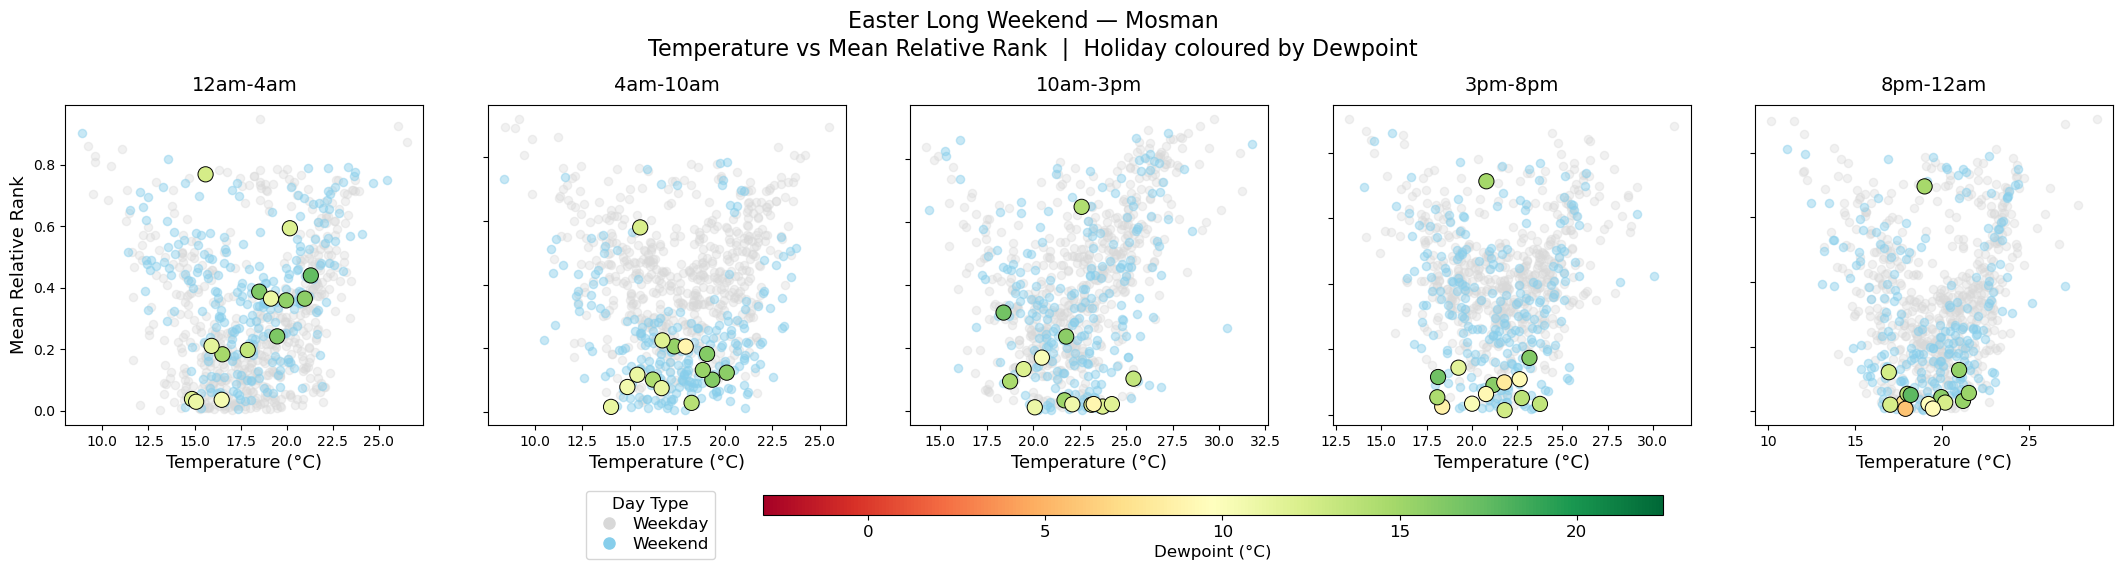

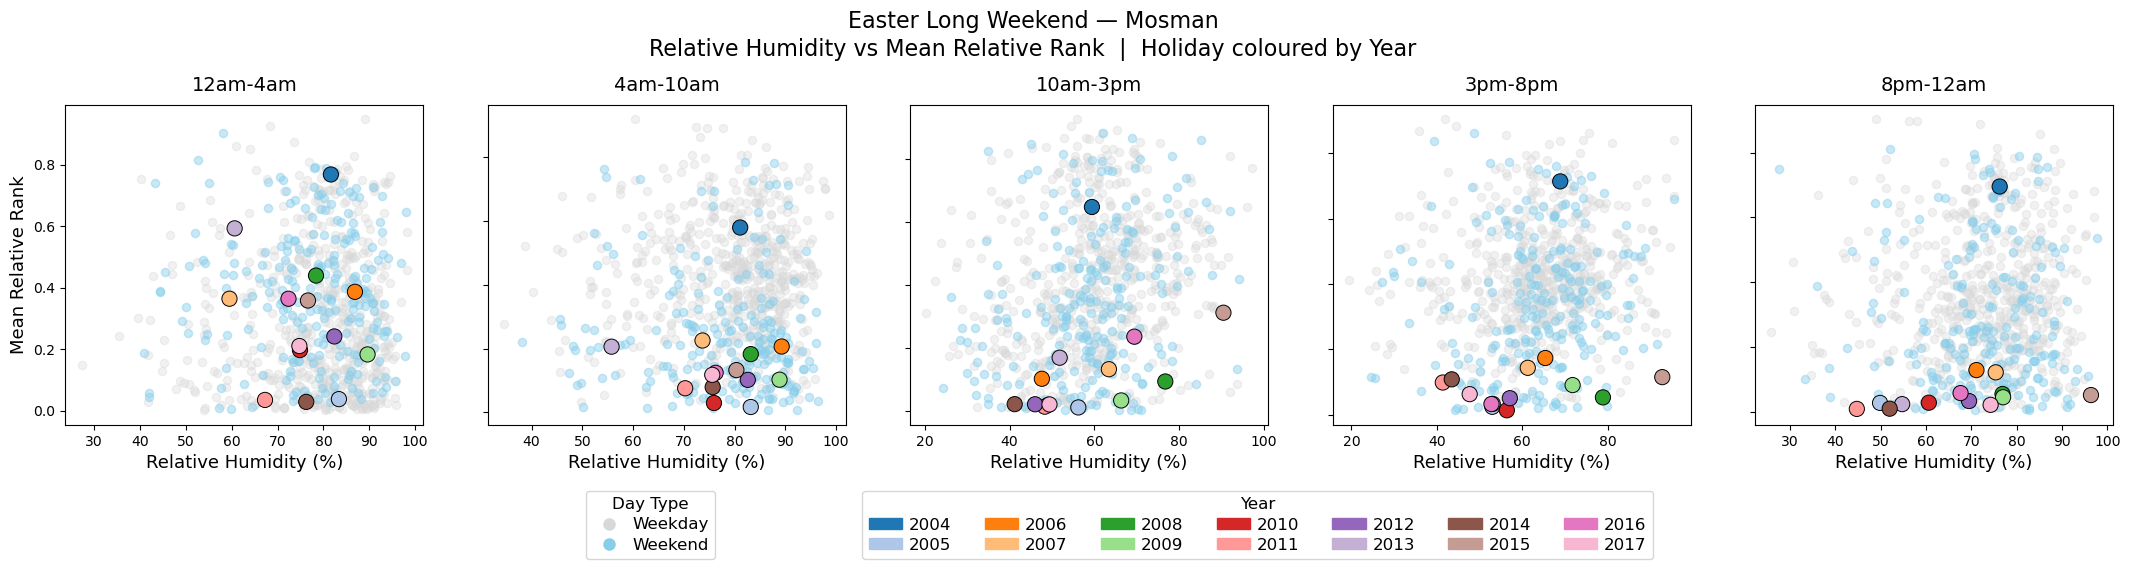

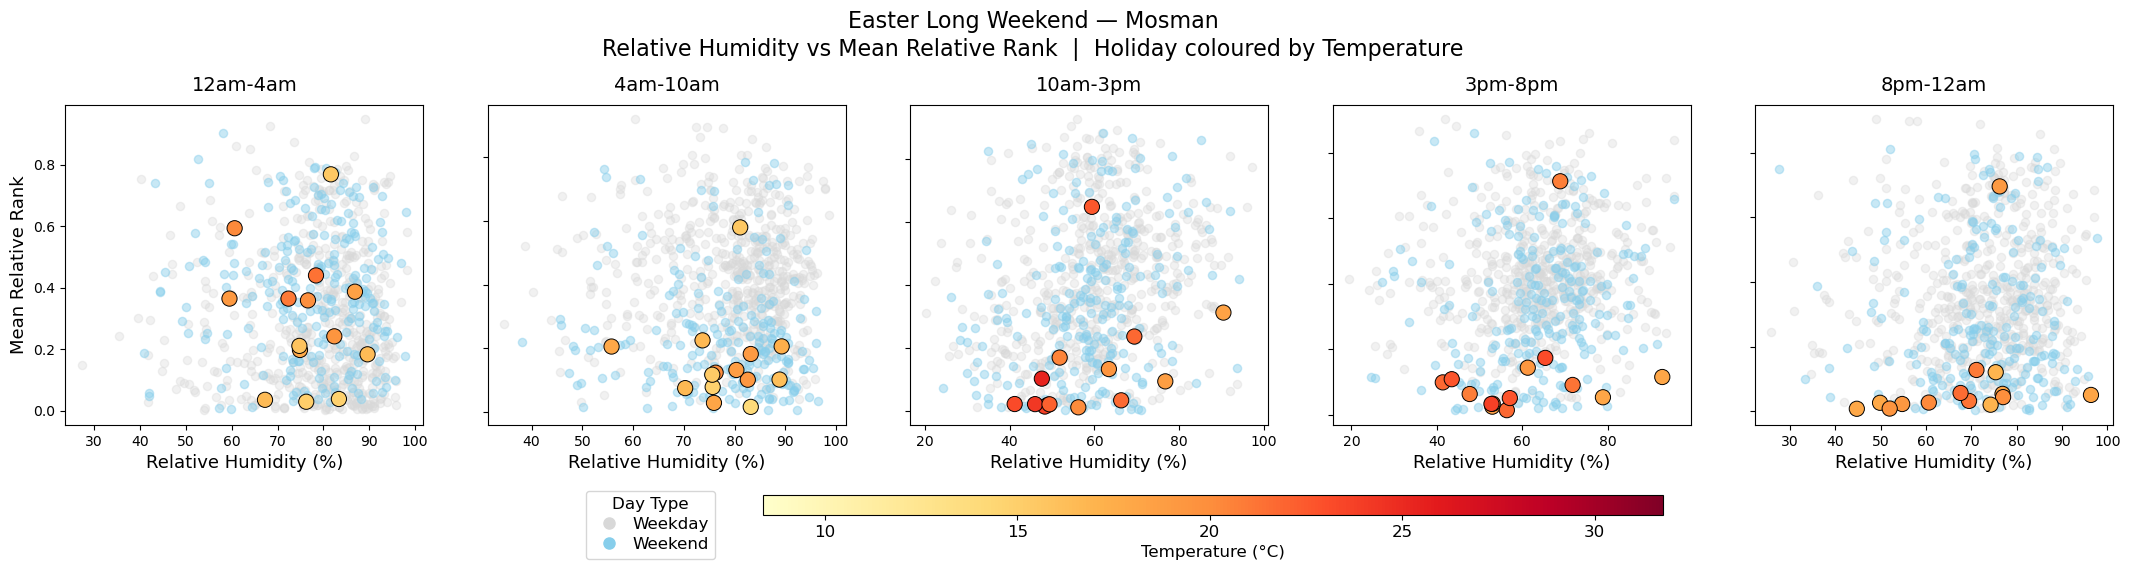

In [14]:
test_holiday = "Easter Long Weekend"
print(f"Testing with: {test_holiday}")

fig1 = plot_temp_dewpoint_scatter(paired, test_holiday)
plt.show()

fig2 = plot_rh_year_scatter(paired, test_holiday)
plt.show()

fig3 = plot_rh_temp_scatter(paired, test_holiday)
plt.show()

# 7. save all

In [15]:
save_dir = "/home/565/pv3484/aus_substation_electricity/data/figures/multi_dimension_mean_rank/seminar_mosma"

plot_types = {
    "temp_dewpoint": plot_temp_dewpoint_scatter,
    "rh_year":       plot_rh_year_scatter,
    "rh_temp":       plot_rh_temp_scatter,
}

for plot_type, plot_func in plot_types.items():
    folder = os.path.join(save_dir, plot_type)
    os.makedirs(folder, exist_ok=True)

    for holiday in paired["holiday_group"].dropna().unique():
        fig = plot_func(paired, holiday)
        if fig is not None:
            holiday_slug = holiday.replace(" ", "_").replace("'", "")
            save_path = os.path.join(folder, f"{holiday_slug}_{station_code}.png")
            fig.savefig(save_path, bbox_inches="tight", dpi=150)
            plt.close(fig)
            print(f"Saved: {plot_type}/{holiday_slug}")

print("Done.")

Saved: temp_dewpoint/New_Years_Day
Saved: temp_dewpoint/Australia_Day
Saved: temp_dewpoint/Good_Friday
Saved: temp_dewpoint/Easter_Saturday
Saved: temp_dewpoint/Easter_Sunday
Saved: temp_dewpoint/Easter_Monday
Saved: temp_dewpoint/ANZAC_Day
Saved: temp_dewpoint/Monarchs_Birthday
Saved: temp_dewpoint/Christmas_Day
Saved: temp_dewpoint/Boxing_Day
Saved: temp_dewpoint/Easter_Long_Weekend
Saved: temp_dewpoint/Christmas_and_Boxing_Day
Saved: rh_year/New_Years_Day
Saved: rh_year/Australia_Day
Saved: rh_year/Good_Friday
Saved: rh_year/Easter_Saturday
Saved: rh_year/Easter_Sunday
Saved: rh_year/Easter_Monday
Saved: rh_year/ANZAC_Day
Saved: rh_year/Monarchs_Birthday
Saved: rh_year/Christmas_Day
Saved: rh_year/Boxing_Day
Saved: rh_year/Easter_Long_Weekend
Saved: rh_year/Christmas_and_Boxing_Day
Saved: rh_temp/New_Years_Day
Saved: rh_temp/Australia_Day
Saved: rh_temp/Good_Friday
Saved: rh_temp/Easter_Saturday
Saved: rh_temp/Easter_Sunday
Saved: rh_temp/Easter_Monday
Saved: rh_temp/ANZAC_Day
Saved

# Seminar Plot layering

In [ ]:
# --- Temp/Dewpoint: weekday only ---
def plot_temp_dewpoint_scatter_weekdays(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df = df[~df['is_weekend'] & ~df['is_holiday']]
    if df.empty:
        print(f'No weekday data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.0), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        x_col    = f'temp_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or x_col not in df.columns or df[x_col].isna().all():
            ax.set_visible(False)
            continue

        ax.scatter(df[x_col], df[rank_col],
                   color=weekday_color, s=60, edgecolor='black',
                   linewidth=0.4, zorder=2, alpha=0.8)

        ax.set_xlabel('Temperature (°C)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Temperature vs Mean Relative Rank  |  Weekdays only',
        fontsize=16, y=1.02, linespacing=1.3
    )

    fig.subplots_adjust(top=0.82, bottom=0.12, left=0.07, right=0.98, wspace=0.18)
    return fig


# --- Temp/Dewpoint: weekday + weekend, no public holiday ---
def plot_temp_dewpoint_scatter_non_holiday(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df = df[~df['is_holiday']]
    if df.empty:
        print(f'No non-holiday data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    weekend_color = 'skyblue'
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.5), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        x_col    = f'temp_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or x_col not in df.columns or df[x_col].isna().all():
            ax.set_visible(False)
            continue

        wd = df[~df['is_weekend']]
        we = df[df['is_weekend']]

        ax.scatter(wd[x_col], wd[rank_col], color=weekday_color, s=60,
                   edgecolor='black', linewidth=0.4, zorder=1, alpha=0.8)
        ax.scatter(we[x_col], we[rank_col], color=weekend_color, s=60,
                   edgecolor='black', linewidth=0.4, zorder=2, alpha=0.8)

        ax.set_xlabel('Temperature (°C)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Temperature vs Mean Relative Rank  |  Excl. Public Holidays',
        fontsize=16, y=1.05, linespacing=1.3
    )

    weekday_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekday_color,
                                markeredgecolor='black', markeredgewidth=0.4, markersize=8, label='Weekday')
    weekend_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekend_color,
                                markeredgecolor='black', markeredgewidth=0.4, markersize=8, label='Weekend')
    fig.legend(handles=[weekday_handle, weekend_handle],
               title='Day Type', title_fontsize=11, fontsize=11,
               loc='lower center', bbox_to_anchor=(0.55, -0.02),
               borderpad=0.4, labelspacing=0.3, handletextpad=0.4, ncol=2, frameon=True)

    fig.subplots_adjust(top=0.88, bottom=0.20, left=0.07, right=0.98, wspace=0.18)
    return fig


fig = plot_temp_dewpoint_scatter_non_holiday(paired, 'Easter Long Weekend', station_full_name='Mosman')
plt.show()

# --- RH/Temp: weekday only ---
def plot_rh_temp_scatter_weekdays(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df = df[~df['is_weekend'] & ~df['is_holiday']]
    if df.empty:
        print(f'No weekday data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.0), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        rh_col   = f'relative_humidity_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or rh_col not in df.columns or df[rh_col].isna().all():
            ax.set_visible(False)
            continue

        ax.scatter(df[rh_col], df[rank_col],
                   color=weekday_color, s=60, edgecolor='black',
                   linewidth=0.4, zorder=2, alpha=0.8)

        ax.set_xlabel('Relative Humidity (%)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Relative Humidity vs Mean Relative Rank  |  Weekdays only',
        fontsize=16, y=1.02, linespacing=1.3
    )

    fig.subplots_adjust(top=0.82, bottom=0.12, left=0.07, right=0.98, wspace=0.18)
    return fig


# --- RH/Temp: weekday + weekend, no public holiday ---
def plot_rh_temp_scatter_non_holiday(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df = df[~df['is_holiday']]
    if df.empty:
        print(f'No non-holiday data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    weekend_color = 'skyblue'
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.0), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        rh_col   = f'relative_humidity_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or rh_col not in df.columns or df[rh_col].isna().all():
            ax.set_visible(False)
            continue

        wd = df[~df['is_weekend']]
        we = df[df['is_weekend']]

        ax.scatter(wd[rh_col], wd[rank_col], color=weekday_color, s=60,
                   edgecolor='black', linewidth=0.4, zorder=1, alpha=0.8)
        ax.scatter(we[rh_col], we[rank_col], color=weekend_color, s=60,
                   edgecolor='black', linewidth=0.4, zorder=2, alpha=0.8)

        ax.set_xlabel('Relative Humidity (%)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Relative Humidity vs Mean Relative Rank  |  Excl. Public Holidays',
        fontsize=16, y=1.02, linespacing=1.3
    )

    weekday_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekday_color,
                                markeredgecolor='black', markeredgewidth=0.4, markersize=8, label='Weekday')
    weekend_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekend_color,
                                markeredgecolor='black', markeredgewidth=0.4, markersize=8, label='Weekend')
    fig.legend(handles=[weekday_handle, weekend_handle],
               title='Day Type', title_fontsize=12, fontsize=12,
               loc='lower left', bbox_to_anchor=(0.07, 0.01),
               borderpad=0.4, labelspacing=0.3, handletextpad=0.4, ncol=2, frameon=True)

    fig.subplots_adjust(top=0.82, bottom=0.18, left=0.07, right=0.98, wspace=0.18)
    return fig

In [ ]:
# --- Temp/Dewpoint: weekday only ---
def plot_temp_dewpoint_scatter_weekdays(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df = df[~df['is_weekend'] & ~df['is_holiday']]
    if df.empty:
        print(f'No weekday data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    dp_cmap = plt.cm.RdYlGn
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    dp_cols_all = [f'dewpoint_{b}' for b in time_blocks if f'dewpoint_{b}' in df.columns]
    dp_global_min = df[dp_cols_all].min().min()
    dp_global_max = df[dp_cols_all].max().max()
    dp_norm = Normalize(vmin=dp_global_min, vmax=dp_global_max)

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.0), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        x_col    = f'temp_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or x_col not in df.columns or df[x_col].isna().all():
            ax.set_visible(False)
            continue

        ax.scatter(df[x_col], df[rank_col],
                   color=weekday_color, s=60, edgecolor='black',
                   linewidth=0.4, zorder=2, alpha=0.8)

        ax.set_xlabel('Temperature (°C)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Temperature vs Mean Relative Rank  |  Weekdays only',
        fontsize=16, y=1.05, linespacing=1.3
    )

    fig.subplots_adjust(top=0.86, bottom=0.10, left=0.07, right=0.98, wspace=0.18)
    return fig

In [ ]:
# --- RH/Temp: weekday only ---
def plot_rh_temp_scatter_weekdays(
    paired,
    holiday_name,
    station_code='MOSMA',
    station_full_name='Mosman',
    time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df = df[~df['is_weekend'] & ~df['is_holiday']]
    if df.empty:
        print(f'No weekday data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.0), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        rh_col   = f'relative_humidity_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or rh_col not in df.columns or df[rh_col].isna().all():
            ax.set_visible(False)
            continue

        ax.scatter(df[rh_col], df[rank_col],
                   color=weekday_color, s=60, edgecolor='black',
                   linewidth=0.4, zorder=2, alpha=0.8)

        ax.set_xlabel('Relative Humidity (%)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Relative Humidity vs Mean Relative Rank  |  Weekdays only',
        fontsize=16, y=1.05, linespacing=1.3
    )

    fig.subplots_adjust(top=0.86, bottom=0.10, left=0.07, right=0.98, wspace=0.18)
    return fig

## Loop and save

In [ ]:
import os

def save_layered_scatters(paired, holiday_names, station_code='MOSMA', station_full_name='Mosman'):
    
    base_dir = '/home/565/pv3484/aus_substation_electricity/pia_notebooks/NSW_data/relative_ranking/seminar_MOSMA_PUNCH/layered_scatters'
    
    weekday_dir = os.path.join(base_dir, 'weekday_only')
    non_holiday_dir = os.path.join(base_dir, 'weekday_weekend')
    
    os.makedirs(weekday_dir, exist_ok=True)
    os.makedirs(non_holiday_dir, exist_ok=True)

    for holiday in holiday_names:
        print(f'Processing: {holiday}')
        safe_name = holiday.replace(' ', '_').replace('/', '-')

        # --- weekday only ---
        fig = plot_temp_dewpoint_scatter_weekdays(
            paired, holiday, station_code=station_code, station_full_name=station_full_name
        )
        if fig is not None:
            path = os.path.join(weekday_dir, f'{safe_name}_temp_dewpoint_weekday.png')
            fig.savefig(path, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f'  Saved: {path}')

        fig = plot_rh_temp_scatter_weekdays(
            paired, holiday, station_code=station_code, station_full_name=station_full_name
        )
        if fig is not None:
            path = os.path.join(weekday_dir, f'{safe_name}_rh_temp_weekday.png')
            fig.savefig(path, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f'  Saved: {path}')

        # --- weekday + weekend (no public holiday) ---
        fig = plot_temp_dewpoint_scatter_non_holiday(
            paired, holiday, station_code=station_code, station_full_name=station_full_name
        )
        if fig is not None:
            path = os.path.join(non_holiday_dir, f'{safe_name}_temp_dewpoint_non_holiday.png')
            fig.savefig(path, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f'  Saved: {path}')

        fig = plot_rh_temp_scatter_non_holiday(
            paired, holiday, station_code=station_code, station_full_name=station_full_name
        )
        if fig is not None:
            path = os.path.join(non_holiday_dir, f'{safe_name}_rh_temp_non_holiday.png')
            fig.savefig(path, dpi=150, bbox_inches='tight')
            plt.close(fig)
            print(f'  Saved: {path}')

    print('Done.')

In [ ]:
holiday_names = paired['holiday_group'].unique()
save_layered_scatters(paired, holiday_names)

In [ ]:
# just plotting easter long weekend

fig = plot_temp_dewpoint_scatter_non_holiday(
    paired,
    holiday_name='Easter Long Weekend',
    station_full_name='Mosman'
)
plt.show()

In [ ]:
fig = plot_temp_dewpoint_scatter_non_holiday(paired, 'Easter Long Weekend', station_full_name='Mosman')

save_path = '/home/565/pv3484/aus_substation_electricity/pia_notebooks/NSW_data/relative_ranking/seminar_MOSMA_PUNCH/layered_scatters/weekday_weekend/mosman/Easter_Long_Weekend_temp_dewpoint_non_holiday_MOSMA.png'

fig.savefig(save_path, dpi=150, bbox_inches='tight')
plt.close(fig)
print(f'Saved: {save_path}')

# Adding a line of best fit to the easter long weekend 12am - 4am

In [ ]:
def plot_temp_dewpoint_scatter_non_holiday(
    paired, holiday_name, station_code='MOSMA',
    station_full_name='Mosman', time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df = df[~df['is_holiday']]
    if df.empty:
        print(f'No non-holiday data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    weekend_color = 'skyblue'
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.5), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        x_col    = f'temp_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or x_col not in df.columns or df[x_col].isna().all():
            ax.set_visible(False)
            continue

        wd = df[~df['is_weekend']]
        we = df[df['is_weekend']]

        ax.scatter(wd[x_col], wd[rank_col], color=weekday_color, s=60,
                   edgecolor='black', linewidth=0.4, zorder=1, alpha=0.8)
        ax.scatter(we[x_col], we[rank_col], color=weekend_color, s=60,
                   edgecolor='black', linewidth=0.4, zorder=2, alpha=0.8)

        valid = df[[x_col, rank_col]].dropna()
        if len(valid) >= 3:
            coeffs = np.polyfit(valid[x_col], valid[rank_col], 2)
            x_fit = np.linspace(valid[x_col].min(), valid[x_col].max(), 200)
            y_fit = np.polyval(coeffs, x_fit)
            ax.plot(x_fit, y_fit, color='black', linewidth=1.5, zorder=3)

            y_pred = np.polyval(coeffs, valid[x_col])
            ss_res = np.sum((valid[rank_col] - y_pred) ** 2)
            ss_tot = np.sum((valid[rank_col] - valid[rank_col].mean()) ** 2)
            r2 = 1 - (ss_res / ss_tot)
            ax.text(0.05, 0.95, f'$R^2 = {r2:.3f}$',
                    transform=ax.transAxes, fontsize=11,
                    verticalalignment='top')

        ax.set_xlabel('Temperature (°C)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Temperature vs Mean Relative Rank  |  Excl. Public Holidays',
        fontsize=16, y=1.05, linespacing=1.3
    )

    weekday_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekday_color,
                                markeredgecolor='black', markeredgewidth=0.4, markersize=8, label='Weekday')
    weekend_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekend_color,
                                markeredgecolor='black', markeredgewidth=0.4, markersize=8, label='Weekend')
    fig.legend(handles=[weekday_handle, weekend_handle],
               title='Day Type', title_fontsize=11, fontsize=11,
               loc='lower center', bbox_to_anchor=(0.55, -0.02),
               borderpad=0.4, labelspacing=0.3, handletextpad=0.4, ncol=2, frameon=True)

    fig.subplots_adjust(top=0.88, bottom=0.20, left=0.07, right=0.98, wspace=0.18)
    return fig


fig = plot_temp_dewpoint_scatter_non_holiday(paired, 'Easter Long Weekend', station_full_name='Mosman')
plt.show()

In [ ]:
def plot_temp_dewpoint_scatter_non_holiday(
    paired, holiday_name, station_code='MOSMA',
    station_full_name='Mosman', time_blocks=None
):
    if time_blocks is None:
        time_blocks = ['00_04', '04_10', '10_15', '15_20', '20_24']

    df = paired[paired['holiday_group'] == holiday_name].copy()
    if df.empty:
        print(f'No data for {holiday_name}')
        return None

    df = df[~df['is_holiday']]
    if df.empty:
        print(f'No non-holiday data for {holiday_name}')
        return None

    weekday_color = '#D8D8D8'
    weekend_color = 'skyblue'
    block_titles = ['12am-4am', '4am-10am', '10am-3pm', '3pm-8pm', '8pm-12am']

    fig, axes = plt.subplots(1, len(time_blocks), figsize=(4.5 * len(time_blocks), 5.5), sharey=False)

    for col_idx, block in enumerate(time_blocks):
        ax = axes[col_idx]
        rank_col = f'{block}_mean_relative_rank'
        x_col    = f'temp_{block}'

        ax.set_title(block_titles[col_idx], fontsize=14, pad=10)

        if rank_col not in df.columns or x_col not in df.columns or df[x_col].isna().all():
            ax.set_visible(False)
            continue

        wd = df[~df['is_weekend']]
        we = df[df['is_weekend']]

        ax.scatter(wd[x_col], wd[rank_col], color=weekday_color, s=60,
                   edgecolor='black', linewidth=0.4, zorder=1, alpha=0.8)
        ax.scatter(we[x_col], we[rank_col], color=weekend_color, s=60,
                   edgecolor='black', linewidth=0.4, zorder=2, alpha=0.8)

        # Quadratic fit — weekdays
        valid_wd = wd[[x_col, rank_col]].dropna()
        if len(valid_wd) >= 3:
            coeffs_wd = np.polyfit(valid_wd[x_col], valid_wd[rank_col], 2)
            x_fit = np.linspace(valid_wd[x_col].min(), valid_wd[x_col].max(), 200)
            ax.plot(x_fit, np.polyval(coeffs_wd, x_fit), color='#555555', linewidth=1.5, zorder=3, linestyle='--')
            y_pred_wd = np.polyval(coeffs_wd, valid_wd[x_col])
            ss_res = np.sum((valid_wd[rank_col] - y_pred_wd) ** 2)
            ss_tot = np.sum((valid_wd[rank_col] - valid_wd[rank_col].mean()) ** 2)
            r2_wd = 1 - (ss_res / ss_tot)
            ax.text(0.05, 0.95, f'$R^2_{{wd}} = {r2_wd:.3f}$',
                    transform=ax.transAxes, fontsize=11,
                    verticalalignment='top', color='#555555')

        # Quadratic fit — weekends
        valid_we = we[[x_col, rank_col]].dropna()
        if len(valid_we) >= 3:
            coeffs_we = np.polyfit(valid_we[x_col], valid_we[rank_col], 2)
            x_fit = np.linspace(valid_we[x_col].min(), valid_we[x_col].max(), 200)
            ax.plot(x_fit, np.polyval(coeffs_we, x_fit), color='steelblue', linewidth=1.5, zorder=3)
            y_pred_we = np.polyval(coeffs_we, valid_we[x_col])
            ss_res = np.sum((valid_we[rank_col] - y_pred_we) ** 2)
            ss_tot = np.sum((valid_we[rank_col] - valid_we[rank_col].mean()) ** 2)
            r2_we = 1 - (ss_res / ss_tot)
            ax.text(0.05, 0.88, f'$R^2_{{we}} = {r2_we:.3f}$',
                    transform=ax.transAxes, fontsize=11,
                    verticalalignment='top', color='steelblue')

        ax.set_xlabel('Temperature (°C)', fontsize=13)
        if col_idx == 0:
            ax.set_ylabel('Mean Relative Rank', fontsize=13)
        else:
            ax.set_ylabel('')
            ax.tick_params(axis='y', labelleft=False)

        ax.tick_params(axis='both', labelsize=10)
        ax.margins(0.05)

    fig.suptitle(
        f'{holiday_name} — {station_full_name}\n'
        f'Temperature vs Mean Relative Rank  |  Excl. Public Holidays',
        fontsize=16, y=1.05, linespacing=1.3
    )

    weekday_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekday_color,
                                markeredgecolor='black', markeredgewidth=0.4, markersize=8, label='Weekday')
    weekend_handle = plt.Line2D([], [], marker='o', linestyle='', color=weekend_color,
                                markeredgecolor='black', markeredgewidth=0.4, markersize=8, label='Weekend')
    fig.legend(handles=[weekday_handle, weekend_handle],
               title='Day Type', title_fontsize=11, fontsize=11,
               loc='lower center', bbox_to_anchor=(0.55, -0.02),
               borderpad=0.4, labelspacing=0.3, handletextpad=0.4, ncol=2, frameon=True)

    fig.subplots_adjust(top=0.88, bottom=0.20, left=0.07, right=0.98, wspace=0.18)
    return fig


fig = plot_temp_dewpoint_scatter_non_holiday(paired, 'Easter Long Weekend', station_full_name='Mosman')
plt.show()

# Temperature on NY day 2006

In [ ]:
# First, check what the date column looks like
print(weather.columns.tolist())
print(weather.head())

In [ ]:
NY_day_2006 = weather[weather['date'] == '2006-01-01']
print("Max temp:", NY_day_2007['temp'].max())
print("Min temp:", NY_day_2007['temp'].min())
print("Mean temp:", NY_day_2007['temp'].mean().round(1))

In [ ]:
weather_raw = pd.read_csv("/home/565/pv3484/aus_substation_electricity/data/BOM_NSW_weather_processed_v1/weather_station_066062.csv")

print(weather_raw.columns.tolist())
print(weather_raw.head())

In [ ]:
christmas_raw = weather_raw[weather_raw['4'].str.startswith('01/01/2006')]

print("=== Raw v1 New Years Day 2006 ===")
print("Temp (col 10) max:", pd.to_numeric(christmas_raw['10'], errors='coerce').max())
print("Temp (col 10) min:", pd.to_numeric(christmas_raw['10'], errors='coerce').min())
print("Temp (col 10) mean:", round(pd.to_numeric(christmas_raw['10'], errors='coerce').mean(), 1))



In [ ]:
# Clean the 'N, ' prefix and extract just the number
nyd_raw = weather_raw[weather_raw['4'].str.startswith('01/01/2006', na=False)]
temp_clean = nyd_raw['10'].str.replace('N,', '').str.strip()
temp_numeric = pd.to_numeric(temp_clean, errors='coerce')

print("=== Raw v1 New Years Day 2006 ===")
print("Rows found:", len(nyd_raw))
print("Temp max:", temp_numeric.max())
print("Temp min:", temp_numeric.min())
print("Temp mean:", round(temp_numeric.mean(), 1))

print("\n=== Processed v3 New Years Day 2006 ===")
print("Max:", nyd_2006['temp'].max())
print("Min:", nyd_2006['temp'].min())
print("Mean:", round(nyd_2006['temp'].mean(), 1))

In [ ]:
# Find the time of max temperature
max_temp_idx = temp_numeric.idxmax()
print("Max temp:", temp_numeric.max())
print("Time of max temp:", nyd_raw.loc[max_temp_idx, '4'])

In [ ]:
# Find time of max temp in processed v3
max_idx = nyd_2006['temp'].idxmax()
print("Max temp:", nyd_2006.loc[max_idx, 'temp'])
print("Time of max temp:", nyd_2006.loc[max_idx, 'timestamp_local'])

In [ ]:
# Check if timestamp_local vs date+time_block align correctly
print(nyd_2006[['timestamp_local', 'date', 'time_block', 'temp']].sort_values('temp', ascending=False).head(5))

# Also check the UTC timestamp at the max
print(nyd_2006.loc[max_idx, 'timestamp_utc'])